# 特別編：完全版汎用デコーダの完成とノイズへの挑戦

<a href="https://github.com/Tsukumo-999/qr-code-from-scratch/blob/master/Step3/full_decoder_final.ipynb" target="_parent">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

QRコード・デコードシリーズの完結編です。これまで学んできた画像処理とエラー訂正アルゴリズム（BM法・チェン探索・フォルニー法）をすべて統合し、１つの完全なデコーダ関数を作成します。

**【事前準備】**
Colabの左側メニューの「ファイル」アイコンを開き、エンコーダで作成した **`qr_hello.png`** と、ペイントソフト等でデータ領域に少し線を引いて意図的に汚した **`qr_hello_dirty.png`** をアップロードしてから実行してください。
（※四隅の大きな四角は塗りつぶさないでください！）

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

GRID_SIZE = 25 
TARGET_SIDE = 500
CELL_SIZE = TARGET_SIDE / GRID_SIZE

# ==========================================
# 画像処理・ビットマップ抽出関数
# ==========================================
def get_finder_patterns(thresh):
    contours, hierarchy = cv2.findContours(thresh, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
    centers = []
    if hierarchy is None: return centers
    for i in range(len(contours)):
        child_idx = hierarchy[0][i][2]
        if child_idx != -1:
            grandchild_idx = hierarchy[0][child_idx][2]
            if grandchild_idx != -1:
                c = contours[i]
                if cv2.contourArea(c) < 50: continue
                rect = cv2.minAreaRect(c)
                w, h = rect[1]
                if w == 0 or h == 0: continue
                aspect_ratio = max(w, h) / min(w, h)
                if aspect_ratio < 1.5:
                    M = cv2.moments(c)
                    if M["m00"] != 0:
                        cx = M["m10"] / M["m00"]
                        cy = M["m01"] / M["m00"]
                        if not any(np.hypot(cx - ex, cy - ey) < 15 for ex, ey in centers):
                            centers.append(np.array([cx, cy], dtype=np.float32))
    return centers

def sort_finder_patterns(centers):
    pts = np.array(centers)
    d01 = np.linalg.norm(pts[0] - pts[1])
    d12 = np.linalg.norm(pts[1] - pts[2])
    d02 = np.linalg.norm(pts[0] - pts[2])
    max_d = max(d01, d12, d02)
    if max_d == d01:   tl_idx, tr_idx, bl_idx = 2, 0, 1
    elif max_d == d12: tl_idx, tr_idx, bl_idx = 0, 1, 2
    else:              tl_idx, tr_idx, bl_idx = 1, 0, 2
    TL = pts[tl_idx]
    if np.cross(pts[tr_idx] - TL, pts[bl_idx] - TL) > 0:
        TR, BL = pts[tr_idx], pts[bl_idx]
    else:
        TR, BL = pts[bl_idx], pts[tr_idx]
    return TL, TR, BL

def process_qr_image(img_path):
    print(f"\n📸 画像読み込み: {img_path}")
    img = cv2.imread(img_path)
    if img is None:
        print(f"エラー: 画像 '{img_path}' が見つかりません。アップロードを確認してください。")
        return None
        
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    thresh = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, 21, 5)
    centers = get_finder_patterns(thresh)
    if len(centers) < 3:
        print("エラー: ファインダパタンが検出できませんでした。ノイズがパタンに被っていませんか？")
        return None
        
    TL, TR, BL = sort_finder_patterns(centers[:3])
    estimated_BR = TR + BL - TL
    
    offset = 3.5 * CELL_SIZE
    far_offset = (GRID_SIZE - 3.5) * CELL_SIZE
    src_pts = np.float32([TL, TR, BL, estimated_BR])
    dst_pts = np.float32([
        [offset, offset], [far_offset, offset],
        [offset, far_offset], [far_offset, far_offset]
    ])
    
    M = cv2.getPerspectiveTransform(src_pts, dst_pts)
    warped = cv2.warpPerspective(img, M, (TARGET_SIDE, TARGET_SIDE))
    warped_gray = cv2.cvtColor(warped, cv2.COLOR_BGR2GRAY)
    _, warped_thresh = cv2.threshold(warped_gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    
    bit_map = np.zeros((GRID_SIZE, GRID_SIZE), dtype=int)
    for row in range(GRID_SIZE):
        for col in range(GRID_SIZE):
            cx, cy = int((col + 0.5) * CELL_SIZE), int((row + 0.5) * CELL_SIZE)
            bit_map[row, col] = 0 if warped_thresh[cy, cx] > 128 else 1
            
    # 読み込んだ画像のプレビュー
    plt.figure(figsize=(3, 3))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title("Input Image")
    plt.axis('off')
    plt.show()
    
    return bit_map


In [ ]:
# ==========================================
# ガロア体と完全版デコーダ関数の統合
# ==========================================

exp_table = [0] * 256
log_table = [0] * 256
v = 1
for i in range(255):
    exp_table[i] = v
    log_table[v] = i
    v <<= 1
    if v & 0x100: v ^= 0x11D
exp_table[255] = exp_table[0]

def gf_mul(x, y):
    if x == 0 or y == 0: return 0
    return exp_table[(log_table[x] + log_table[y]) % 255]

def gf_div(x, y):
    if y == 0: raise ZeroDivisionError("0除算")
    if x == 0: return 0
    return exp_table[(log_table[x] - log_table[y]) % 255]

def decode_qr(bit_map):
    print("===== 汎用デコーダ 解析開始 =====")
    
    # 1. フォーマット情報取得とマスク解除
    format_coords = [(0,8), (1,8), (2,8), (3,8), (4,8), (5,8), (7,8), (8,8), (8,7), (8,5), (8,4), (8,3), (8,2), (8,1), (8,0)]
    fmt_code = 0
    for i, (x, y) in enumerate(format_coords):
        fmt_code |= (bit_map[y][x] << (14 - i))
    
    unmasked_fmt = fmt_code ^ 0b101010000010010
    mask_pattern_bits = (unmasked_fmt >> 10) & 0b111
    print(f"[1] マスクパターンを認識: {format(mask_pattern_bits, '03b')}")
    
    def mask_condition(x, y):
        if mask_pattern_bits == 0: return (x + y) % 2 == 0
        if mask_pattern_bits == 1: return y % 2 == 0
        if mask_pattern_bits == 2: return x % 3 == 0
        if mask_pattern_bits == 3: return (x + y) % 3 == 0
        if mask_pattern_bits == 4: return (y // 2 + x // 3) % 2 == 0
        if mask_pattern_bits == 5: return ((x * y) % 2) + ((x * y) % 3) == 0
        if mask_pattern_bits == 6: return (((x * y) % 2) + ((x * y) % 3)) % 2 == 0
        if mask_pattern_bits == 7: return (((x + y) % 2) + ((x * y) % 3)) % 2 == 0
        return False

    def is_reserved(x, y):
        if (0 <= x <= 8 and 0 <= y <= 8) or (GRID_SIZE - 8 <= x < GRID_SIZE and 0 <= y <= 8) or (0 <= x <= 8 and GRID_SIZE - 8 <= y < GRID_SIZE): return True
        if x == 6 or y == 6: return True
        if 16 <= x <= 20 and 16 <= y <= 20: return True
        return False

    unmasked_matrix = [row[:] for row in bit_map]
    for y in range(GRID_SIZE):
        for x in range(GRID_SIZE):
            if not is_reserved(x, y) and mask_condition(x, y):
                unmasked_matrix[y][x] ^= 1

    # 2. ジグザグスキャンとコード語抽出
    extracted_bits = []
    x = GRID_SIZE - 1
    upward = True
    while x > 0:
        if x == 6: x -= 1
        y_range = range(GRID_SIZE - 1, -1, -1) if upward else range(GRID_SIZE)
        for y in y_range:
            for dx in (0, -1):
                if not is_reserved(x + dx, y):
                    extracted_bits.append(unmasked_matrix[y][x + dx])
        upward = not upward
        x -= 2

    TOTAL_CODEWORDS, EC_CODEWORDS = 44, 22
    received_codewords = [int("".join(map(str, extracted_bits[i:i+8])), 2) for i in range(0, TOTAL_CODEWORDS * 8, 8)]
    print(f"[2] データを抽出完了 ({len(received_codewords)} バイト)")

    # 3. シンドローム検証
    syndromes = []
    for i in range(EC_CODEWORDS):
        syndrome = 0
        for coef in received_codewords:
            syndrome = coef ^ gf_mul(syndrome, exp_table[i])
        syndromes.append(syndrome)
        
    repaired_codewords = received_codewords.copy()
    if all(s == 0 for s in syndromes):
        print("[3] シンドローム検証: エラーなし！完璧なデータです。")
    else:
        print("[3] シンドローム検証: エラーを検出しました。修復プロセスを開始します...")
        
        # BM法
        C = [1]; B = [1]; L = 0; m = 1; b = 1
        for i in range(len(syndromes)):
            d = syndromes[i]
            for j in range(1, L + 1):
                if j < len(C) and (i - j) >= 0:
                    d ^= gf_mul(C[j], syndromes[i - j])
            if d != 0:
                coef = gf_div(d, b)
                term = [0] * m + [gf_mul(coef, c) for c in B]
                next_C = [0] * max(len(C), len(term))
                for k in range(len(next_C)):
                    val_C = C[k] if k < len(C) else 0
                    val_term = term[k] if k < len(term) else 0
                    next_C[k] = val_C ^ val_term
                if 2 * L <= i:
                    L = i + 1 - L; B = C.copy(); b = d; m = 1
                else:
                    m += 1
                C = next_C
            else:
                m += 1
        print(f"  -> [BM法] エラー位置多項式 σ(x) を生成しました。エラーの数は約 {len(C)-1} 個です。")
        
        # チェン探索
        msg_length = len(received_codewords)
        error_positions = []
        for i in range(msg_length):
            x_val = 1 if i == 0 else exp_table[255 - i]
            result, x_pow = 0, 1
            for coef in C:
                result ^= gf_mul(coef, x_pow)
                x_pow = gf_mul(x_pow, x_val)
            if result == 0: error_positions.append(i)
                
        error_indexes = [(msg_length - 1) - i for i in error_positions]
        print(f"  -> [チェン探索] エラー位置(インデックス)を {len(error_indexes)} 箇所特定: {error_indexes}")
        if len(error_positions) > EC_CODEWORDS // 2:
             print("   エラーが修復限界を超えています。デコードを中止します。")
             return None
             
        # フォルニー法
        Omega = [0] * EC_CODEWORDS
        for i in range(EC_CODEWORDS):
            for j in range(len(C)):
                if i - j >= 0 and (i - j) < len(syndromes):
                    Omega[i] ^= gf_mul(C[j], syndromes[i - j])
                    
        for pos in error_positions:
            x_inv = 1 if pos == 0 else exp_table[255 - pos]
            omega_val, x_pow = 0, 1
            for coef in Omega:
                omega_val ^= gf_mul(coef, x_pow)
                x_pow = gf_mul(x_pow, x_inv)
                
            deriv_val, x_pow = 0, 1
            for j in range(1, len(C), 2):
                deriv_val ^= gf_mul(C[j], x_pow)
                x_pow = gf_mul(x_pow, gf_mul(x_inv, x_inv))
                
            error_value = gf_mul(gf_div(omega_val, deriv_val), exp_table[pos])
            idx = (msg_length - 1) - pos
            repaired_codewords[idx] ^= error_value
            print(f"  -> [フォルニー法] インデックス {idx} を正しい値に修復しました！")
            
        print("[4] データの修復がすべて完了しました！")
        
    # 4. デコード (修復後データからテキストへ)
    data_bits_str = "".join([format(c, '08b') for c in repaired_codewords])
    if data_bits_str[0:4] != "0100":
        print("エラー: バイトモード以外のデータが含まれています。")
        return None
        
    char_count = int(data_bits_str[4:12], 2)
    data_bytes = bytearray([int(data_bits_str[i:i+8], 2) for i in range(12, 12 + char_count * 8, 8)])
    
    try:
        decoded_text = data_bytes.decode('ascii')
        print(f"\n デコード結果（文字列復元成功）: {decoded_text} \n")
        return decoded_text
    except Exception as e:
        print(f"文字列のデコードに失敗しました: {e}")
        return None


### 実験1：綺麗なQRコード（Happy Path）のデコード
汚れのない無傷の画像を読み取ります。修復アルゴリズムが発動せず、一瞬で「HELLO」が返ってくることを確認してください。


📸 画像読み込み: qr_hello.png


C:\Users\akiak\AppData\Local\Temp\ipykernel_17796\850345664.py:46: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  if np.cross(pts[tr_idx] - TL, pts[bl_idx] - TL) > 0:


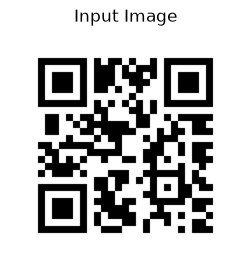

===== 汎用デコーダ 解析開始 =====
[1] マスクパターンを認識: 000
[2] データを抽出完了 (44 バイト)
[3] シンドローム検証: ✅ エラーなし！完璧なデータです。

🌟 デコード結果（文字列復元成功）: HELLO 🌟



In [6]:
IMG_PATH_CLEAN = 'qr_hello.png'

qr_matrix_clean = process_qr_image(IMG_PATH_CLEAN)
if qr_matrix_clean is not None:
    decode_qr(qr_matrix_clean)

### 実験2：汚れやノイズ（Sad Path）への挑戦
いよいよ本番です。ペイント等で意図的にデータを破壊した画像を読み取ります。
裏でリード・ソロモン符号の数式が激しく動き、傷ついたデータを執念で修復して見せる魔法をご覧ください！


📸 画像読み込み: qr_hello_dirty.png


C:\Users\akiak\AppData\Local\Temp\ipykernel_17796\850345664.py:46: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  if np.cross(pts[tr_idx] - TL, pts[bl_idx] - TL) > 0:


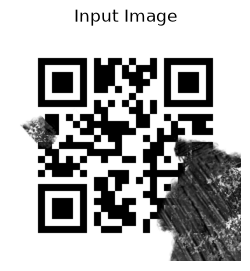

===== 汎用デコーダ 解析開始 =====
[1] マスクパターンを認識: 000
[2] データを抽出完了 (44 バイト)
[3] シンドローム検証: ❌ エラーを検出しました。修復プロセスを開始します...
  -> [BM法] エラー位置多項式 σ(x) を生成しました。エラーの数は約 11 個です。
  -> [チェン探索] エラー位置(インデックス)を 11 箇所特定: [43, 13, 12, 8, 7, 6, 5, 4, 2, 1, 0]
  -> [フォルニー法] インデックス 43 を正しい値に修復しました！
  -> [フォルニー法] インデックス 13 を正しい値に修復しました！
  -> [フォルニー法] インデックス 12 を正しい値に修復しました！
  -> [フォルニー法] インデックス 8 を正しい値に修復しました！
  -> [フォルニー法] インデックス 7 を正しい値に修復しました！
  -> [フォルニー法] インデックス 6 を正しい値に修復しました！
  -> [フォルニー法] インデックス 5 を正しい値に修復しました！
  -> [フォルニー法] インデックス 4 を正しい値に修復しました！
  -> [フォルニー法] インデックス 2 を正しい値に修復しました！
  -> [フォルニー法] インデックス 1 を正しい値に修復しました！
  -> [フォルニー法] インデックス 0 を正しい値に修復しました！
[4] データの修復がすべて完了しました！

🌟 デコード結果（文字列復元成功）: HELLO 🌟



In [8]:
IMG_PATH_DIRTY = 'qr_hello_dirty.png'

qr_matrix_dirty = process_qr_image(IMG_PATH_DIRTY)
if qr_matrix_dirty is not None:
    decode_qr(qr_matrix_dirty)